# 02 - Feature Engineering

Demonstrates `src/features/feature_engineering.py`'s output: price lags, rolling stats, calendar/season features, and lagged exogenous features. Same function every model's `train.py` calls, so this notebook shows exactly what each model sees.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd

from src.utils.io import load_config
from src.features.feature_engineering import build_features, get_feature_columns

config = load_config()
vegetable = 'carrot'
df = pd.read_csv(f'../data/processed/{vegetable}.csv', parse_dates=['date'])
df.shape

(571, 6)

In [2]:
feat = build_features(df, config)
feature_cols = get_feature_columns(feat)
print(f'{len(df)} raw rows -> {len(feat)} rows after dropping lag/rolling warm-up')
print(f'{len(feature_cols)} feature columns:')
feature_cols

571 raw rows -> 559 rows after dropping lag/rolling warm-up
20 feature columns:


['average_temperature',
 'average_rainfall',
 'diesel_price',
 'price_lag_1',
 'price_lag_2',
 'price_lag_4',
 'price_lag_8',
 'price_rolling_mean_4',
 'price_rolling_std_4',
 'price_rolling_mean_8',
 'price_rolling_std_8',
 'price_rolling_mean_12',
 'price_rolling_std_12',
 'month',
 'week_of_year',
 'quarter',
 'is_maha_season',
 'average_temperature_lag_1',
 'average_rainfall_lag_1',
 'diesel_price_lag_1']

In [3]:
feat[['date', 'target'] + feature_cols].head(10)

,date,target,average_temperature,average_rainfall,diesel_price,price_lag_1,price_lag_2,price_lag_4,price_lag_8,price_rolling_mean_4,...,price_rolling_std_8,price_rolling_mean_12,price_rolling_std_12,month,week_of_year,quarter,is_maha_season,average_temperature_lag_1,average_rainfall_lag_1,diesel_price_lag_1
0,2015-03-30,154.76,18.65,9.70,95.0,150.00,142.27,153.57,206.29,146.0425,...,26.576526,205.093333,62.977869,3,14,1,1,18.44,4.50,95.0
1,2015-04-06,171.43,18.53,9.99,95.0,154.76,150.00,138.33,192.90,146.3400,...,22.054439,189.680000,47.850702,4,15,2,1,18.65,9.70,95.0
2,2015-04-13,166.92,18.33,12.34,95.0,171.43,154.76,142.27,195.90,154.6150,...,18.887120,179.655833,35.549812,4,16,2,1,18.53,9.99,95.0
3,2015-04-20,156.19,18.55,11.54,95.0,166.92,171.43,150.00,171.21,160.7775,...,12.721353,172.899167,28.356699,4,17,2,1,18.33,12.34,95.0
4,2015-04-27,154.63,18.61,4.44,95.0,156.19,166.92,154.76,153.57,162.3250,...,11.181372,166.647500,21.857324,4,18,2,1,18.55,11.54,95.0
5,2015-05-04,154.76,18.72,20.09,95.0,154.63,156.19,171.43,138.33,162.2925,...,11.179341,162.342500,18.104909,5,19,2,0,18.61,4.44,95.0
6,2015-05-11,175.00,18.78,8.46,95.0,154.76,154.63,166.92,142.27,158.1250,...,9.147499,159.164167,15.398279,5,20,2,0,18.72,20.09,95.0
7,2015-05-18,201.56,19.46,2.26,95.0,175.00,154.76,156.19,150.00,160.1450,...,9.258953,157.422500,11.572020,5,21,2,0,18.78,8.46,95.0
8,2015-05-25,214.87,19.81,3.29,95.0,201.56,175.00,154.63,154.76,171.4875,...,16.245715,159.951667,16.933806,5,22,2,0,19.46,2.26,95.0
9,2015-06-01,249.71,18.94,6.99,95.0,214.87,201.56,154.76,171.43,186.5475,...,22.516030,165.060000,22.994957,6,23,2,0,19.81,3.29,95.0


## Sanity check: no leakage

Every lag/rolling feature at row *t* must be built strictly from rows before *t*.

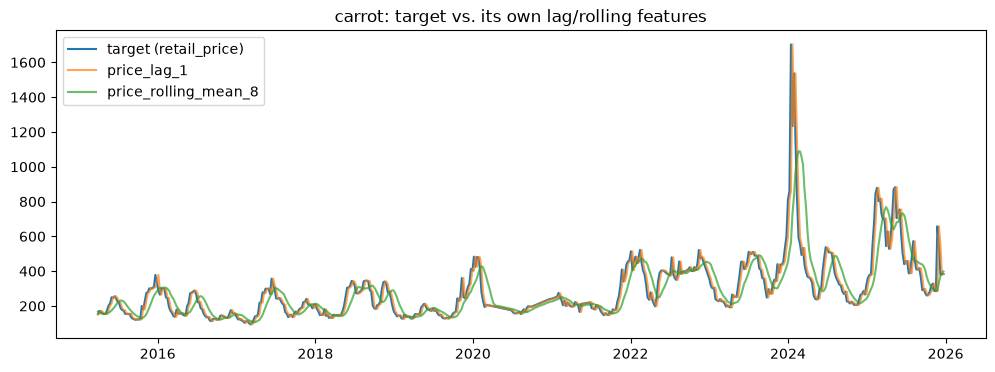

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(feat['date'], feat['target'], label='target (retail_price)')
ax.plot(feat['date'], feat['price_lag_1'], label='price_lag_1', alpha=0.7)
ax.plot(feat['date'], feat['price_rolling_mean_8'], label='price_rolling_mean_8', alpha=0.7)
ax.legend(); ax.set_title(f'{vegetable}: target vs. its own lag/rolling features')
plt.show()

## Maha/Yala season flag

In [5]:
feat.groupby('is_maha_season')['target'].describe()

,count,mean,std,min,25%,50%,75%,max
is_maha_season,,,,,,,,
0,241.0,280.306347,137.320138,112.500000,173.9000,244.705882,365.000000,882.692308
1,318.0,295.337204,199.599149,94.047619,172.4725,230.513393,362.840909,1703.333333


## Feature importance preview (quick Random Forest fit, full data - not the CV/holdout split used for evaluation)

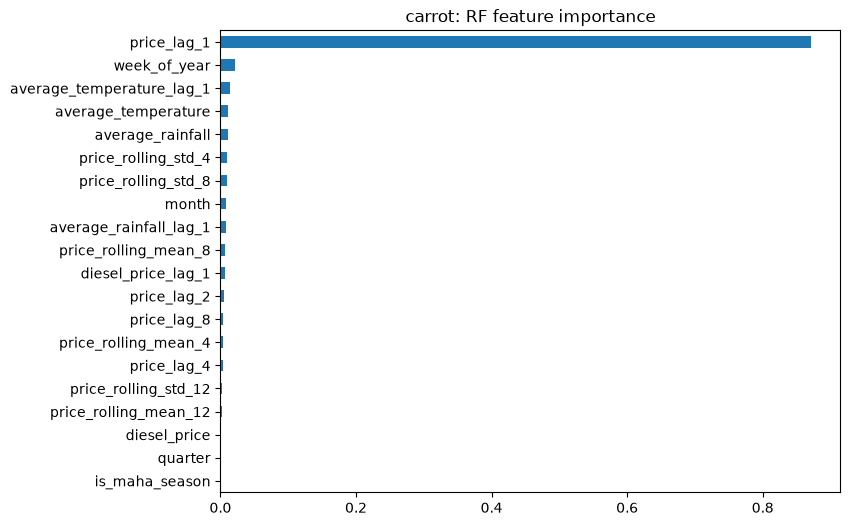

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(feat[feature_cols], feat['target'])
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.plot.barh(figsize=(8, 6)); plt.title(f'{vegetable}: RF feature importance'); plt.gca().invert_yaxis(); plt.show()